In [ ]:
import pandas as pd

file25 = "5. CY2025_Landscape_202506.1.csv"
file26 = "2. CY2026_Landscape_202603.csv"

df25 = pd.read_csv(file25, dtype=str)
df26 = pd.read_csv(file26, dtype=str)

print(df25.shape, df26.shape)
df25.head(2)

(142653, 48) (138263, 52)


,Contract Year,Contract Category Type,State Abbreviation,State Name,County Name,Contract ID,Plan ID,Segment ID,Sanctioned Plan,Contract Name,...,Part C Premium,Monthly Consolidated Premium (Part C + D),In-Network Maximum Out-of-Pocket (MOOP) Amount,Part C Summary Star Rating,Part D Summary Star Rating,Overall Star Rating,MA Region Code,MA Region,PDP Region Code,PDP Region
0,2025,PDP,AK,Alaska,All Counties,S4802,096,0,No,"WELLCARE PRESCRIPTION INSURANCE, INC.",...,Not Applicable,Not Applicable,Not Applicable,Not Applicable,3.5,Not Applicable,Not Applicable,Not Applicable,34,Alaska
1,2025,PDP,AK,Alaska,All Counties,S4802,165,0,No,"WELLCARE PRESCRIPTION INSURANCE, INC.",...,Not Applicable,Not Applicable,Not Applicable,Not Applicable,3.5,Not Applicable,Not Applicable,Not Applicable,34,Alaska


In [ ]:
def norm_text(s):
    return (s.astype(str)
              .str.upper()
              .str.strip()
              .str.replace(r"\s+", " ", regex=True))

# 统一州字段命名
df25 = df25.rename(columns={
    "State Abbreviation": "state_abbr",
    "State Name": "state_name"
})
df26 = df26.rename(columns={
    "State Territory Abbreviation": "state_abbr",
    "State Territory Name": "state_name"
})

# 标准化州/县/母公司名
df25["state_abbr"] = norm_text(df25["state_abbr"])
df26["state_abbr"] = norm_text(df26["state_abbr"])

df25["county_norm"] = norm_text(df25["County Name"])
df26["county_norm"] = norm_text(df26["County Name"])

df25["parent_org_norm"] = norm_text(df25["Parent Organization Name"])
df26["parent_org_norm"] = norm_text(df26["Parent Organization Name"])

In [ ]:
import pandas as pd

keys_mkt = ["state_abbr", "county_norm", "parent_org_norm"]

# 2025/2026 presence（market层：county+parent）
m25 = df25[keys_mkt].drop_duplicates().assign(present_2025=1)
m26 = df26[keys_mkt].drop_duplicates().assign(present_2026=1)

# 市场级退出：2025有、2026无
exit_mkt = (m25.merge(m26, on=keys_mkt, how="left")
              .query("present_2026.isna()", engine="python")
              .drop(columns=["present_2026"]))
print("Exit market rows:", exit_mkt.shape[0])
exit_mkt.head()

Exit market rows: 1644


,state_abbr,county_norm,parent_org_norm,present_2025
464,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1
470,AR,ASHLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1
471,AR,ASHLEY,USABLE MUTUAL INSURANCE COMPANY,1
482,AR,BENTON,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1
489,AR,BOONE,CVS HEALTH CORPORATION,1


In [ ]:
#Contract+Plan
if "ContractPlanID" not in df25.columns:
    df25["ContractPlanID"] = (
        df25["Contract ID"].astype(str).str.strip() + "-" +
        df25["Plan ID"].astype(str).str.strip()
    )

# 2025在每个county-parent下的规模统计
exit_size_25 = (df25.groupby(keys_mkt)
                  .agg(n_contracts_2025=("Contract ID", "nunique"),
                       n_contractplan_2025=("ContractPlanID", "nunique"),
                       n_planid_2025=("Plan ID", "nunique"))
                  .reset_index())

exit_table_A = (exit_mkt.merge(exit_size_25, on=keys_mkt, how="left")
                       .sort_values(["state_abbr","county_norm","parent_org_norm"]))

exit_table_A.head(10)

,state_abbr,county_norm,parent_org_norm,present_2025,n_contracts_2025,n_contractplan_2025,n_planid_2025
0,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4
1,AR,ASHLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4
2,AR,ASHLEY,USABLE MUTUAL INSURANCE COMPANY,1,2,5,5
3,AR,BENTON,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4
4,AR,BOONE,CVS HEALTH CORPORATION,1,1,7,7
5,AR,BRADLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4
6,AR,CALHOUN,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4
7,AR,CARROLL,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4
8,AR,CHICOT,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4
9,AR,CLARK,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,1,1,4,4


In [ ]:
lookup25 = (df25[["state_abbr","county_norm","parent_org_norm","County Name","Parent Organization Name"]]
            .drop_duplicates(subset=["state_abbr","county_norm","parent_org_norm"]))

exit_table_A = exit_table_A.merge(lookup25, on=keys_mkt, how="left")

exit_table_A = exit_table_A[[
    "state_abbr","County Name","Parent Organization Name",
    "n_contracts_2025","n_contractplan_2025","n_planid_2025"
]]

exit_table_A.head(20)

,state_abbr,County Name,Parent Organization Name,n_contracts_2025,n_contractplan_2025,n_planid_2025
0,AR,Arkansas,Louisiana Health Service & Indemnity Company,1,4,4
1,AR,Ashley,Louisiana Health Service & Indemnity Company,1,4,4
2,AR,Ashley,USAble Mutual Insurance Company,2,5,5
3,AR,Benton,Louisiana Health Service & Indemnity Company,1,4,4
4,AR,Boone,CVS Health Corporation,1,7,7
5,AR,Bradley,Louisiana Health Service & Indemnity Company,1,4,4
6,AR,Calhoun,Louisiana Health Service & Indemnity Company,1,4,4
7,AR,Carroll,Louisiana Health Service & Indemnity Company,1,4,4
8,AR,Chicot,Louisiana Health Service & Indemnity Company,1,4,4
9,AR,Clark,Louisiana Health Service & Indemnity Company,1,4,4


In [ ]:
# 先把退出的market key带回到2025明细
detail_cols = ["state_abbr","county_norm","parent_org_norm",
               "Contract ID","Plan ID","Segment ID",
               "Plan Name","Plan Type","SNP Type","Part D Coverage Indicator",
               "Part C Premium","Monthly Consolidated Premium (Part C + D)",
               "In-Network Maximum Out-of-Pocket (MOOP) Amount",
               "Overall Star Rating"]

# 有些列25年可能不存在/名字略不同
detail_cols_exist = [c for c in detail_cols if c in df25.columns]

exit_detail_B = (df25.merge(exit_mkt[keys_mkt], on=keys_mkt, how="inner")
                   [detail_cols_exist]
                   .drop_duplicates()
                   .sort_values(["state_abbr","county_norm","parent_org_norm","Contract ID","Plan ID","Segment ID"]))

# 加回原始展示名
exit_detail_B = exit_detail_B.merge(
    df25[["state_abbr","county_norm","parent_org_norm","County Name","Parent Organization Name"]]
      .drop_duplicates(subset=keys_mkt),
    on=keys_mkt, how="left"
)

exit_detail_B.head(20)

,state_abbr,county_norm,parent_org_norm,Contract ID,Plan ID,Segment ID,Plan Name,Plan Type,SNP Type,Part D Coverage Indicator,Part C Premium,Monthly Consolidated Premium (Part C + D),In-Network Maximum Out-of-Pocket (MOOP) Amount,Overall Star Rating,County Name,Parent Organization Name
0,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,002,0,Primewell Classic (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$0.00,"$4,500.00",3,Arkansas,Louisiana Health Service & Indemnity Company
1,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,003,0,Primewell Dual Plus (HMO-POS D-SNP),HMO-POS D-SNP,Dual-Eligible,Yes,$0.00,$20.90,"$9,350.00",3,Arkansas,Louisiana Health Service & Indemnity Company
2,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,004,0,Primewell Reliance (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$20.90,"$4,100.00",3,Arkansas,Louisiana Health Service & Indemnity Company
3,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,005,0,Primewell Giveback (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$0.00,"$5,400.00",3,Arkansas,Louisiana Health Service & Indemnity Company
4,AR,ASHLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,002,0,Primewell Classic (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$0.00,"$4,500.00",3,Ashley,Louisiana Health Service & Indemnity Company
5,AR,ASHLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,003,0,Primewell Dual Plus (HMO-POS D-SNP),HMO-POS D-SNP,Dual-Eligible,Yes,$0.00,$20.90,"$9,350.00",3,Ashley,Louisiana Health Service & Indemnity Company
6,AR,ASHLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,004,0,Primewell Reliance (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$20.90,"$4,100.00",3,Ashley,Louisiana Health Service & Indemnity Company
7,AR,ASHLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,005,0,Primewell Giveback (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$0.00,"$5,400.00",3,Ashley,Louisiana Health Service & Indemnity Company
8,AR,ASHLEY,USABLE MUTUAL INSURANCE COMPANY,H3554,002,0,BlueMedicare Saver Choice (PPO),PPO,Not Applicable,Yes,$0.00,$0.00,"$6,000.00",3,Ashley,USAble Mutual Insurance Company
9,AR,ASHLEY,USABLE MUTUAL INSURANCE COMPANY,H3554,007,0,BlueMedicare Premier Choice (PPO),PPO,Not Applicable,Yes,$33.70,$49.00,"$5,700.00",3,Ashley,USAble Mutual Insurance Company


In [ ]:
exit_by_county = (exit_table_A.groupby(["state_abbr","County Name"])
                            .agg(num_exiting_carriers=("Parent Organization Name","nunique"))
                            .reset_index()
                            .sort_values("num_exiting_carriers", ascending=False))

exit_by_county.head(20)

,state_abbr,County Name,num_exiting_carriers
502,MN,Crow Wing,4
499,MN,Clearwater,4
525,MN,Lincoln,4
527,MN,Mahnomen,4
544,MN,Polk,4
547,MN,Red Lake,4
541,MN,Pennington,4
543,MN,Pipestone,4
540,MN,Otter Tail,4
538,MN,Norman,4


In [ ]:
# 一般不跑，保存数据用
exit_table_A.to_csv("exit_county_parentorg_2025_only.csv", index=False)
exit_detail_B.to_csv("exit_county_parentorg_plan_detail_2025_only.csv", index=False)
exit_by_county.to_csv("exit_by_county_num_exiting_carriers.csv", index=False)

from google.colab import files
files.download("exit_county_parentorg_2025_only.csv")
files.download("exit_county_parentorg_plan_detail_2025_only.csv")
files.download("exit_by_county_num_exiting_carriers.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 一般不跑，保存数据用
exit_detail_B.to_parquet("exit_detail_B.parquet", index=False)

from google.colab import files
files.download("exit_detail_B.parquet")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import re

files_2025 = [
  "SCC_Enrollment_MA_2025_01.csv","SCC_Enrollment_MA_2025_02.csv",
  "SCC_Enrollment_MA_2025_03.csv","SCC_Enrollment_MA_2025_04.csv",
  "SCC_Enrollment_MA_2025_05.csv","SCC_Enrollment_MA_2025_06.csv",
  "SCC_Enrollment_MA_2025_07.csv","SCC_Enrollment_MA_2025_08.csv",
  "SCC_Enrollment_MA_2025_09.csv","SCC_Enrollment_MA_2025_10.csv",
  "SCC_Enrollment_MA_2025_11.csv","SCC_Enrollment_MA_2025_12.csv"
]
files_2026 = ["SCC_Enrollment_MA_2026_01.csv","SCC_Enrollment_MA_2026_02.csv","SCC_Enrollment_MA_2026_03.csv"]

def clean_enrolled(x):
    x = x.astype(str).str.strip().replace({".": None, "": None})
    return pd.to_numeric(x, errors="coerce").fillna(0).astype(int)

def norm_county(s):
    s = s.astype(str).str.upper().str.strip()
    s = s.str.replace(r"\s+", " ", regex=True)
    # 缩写统一
    s = s.str.replace(r"\bST\.\b", "SAINT", regex=True)
    s = s.str.replace(r"\bSTE\.\b", "SAINTE", regex=True)
    # 去掉后缀
    s = s.str.replace(r"\bCOUNTY\b", "", regex=True)
    s = s.str.replace(r"\bPARISH\b", "", regex=True)
    s = s.str.replace(r"\bBOROUGH\b", "", regex=True)
    s = s.str.replace(r"\bCENSUS AREA\b", "", regex=True)
    s = s.str.replace(r"\bCITY AND BOROUGH\b", "", regex=True)
    s = s.str.replace(r"\bCITY\b", "", regex=True)
    # 去掉标点
    s = s.str.replace(r"[^\w\s]", "", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

def read_enrollment(fp):
    df = pd.read_csv(fp, dtype=str)
    df.columns = df.columns.str.strip()

    m = re.search(r"(20\d{2})[_-](\d{2})", fp)
    period = f"{m.group(1)}-{m.group(2)}" if m else fp

    df["period"] = period
    df["state_abbr"] = df["State"].astype(str).str.upper().str.strip()
    df["county_norm"] = norm_county(df["County"])
    df["Contract ID"] = df["Contract ID"].astype(str).str.upper().str.strip()
    df["Enrolled"] = clean_enrolled(df["Enrolled"])
    return df

enr_all = pd.concat([read_enrollment(f) for f in (files_2025 + files_2026)], ignore_index=True)
print("enr_all shape:", enr_all.shape)
enr_all.head(2)

enr_all shape: (6872628, 12)


,County,State,Contract ID,Organization Name,Organization Type,Plan Type,SSA Code,FIPS Code,Enrolled,period,state_abbr,county_norm
0,Autauga,AL,90091,UNITED MINE WORKERS OF AMERICA HLTH & RETIREMENT,HCPP - 1833 Cost,HCPP - 1833 Cost,01000,01001,0,2025-01,AL,AUTAUGA
1,Autauga,AL,H0104,BLUE CROSS AND BLUE SHIELD OF ALABAMA,Local CCP,Local PPO,01000,01001,946,2025-01,AL,AUTAUGA


In [ ]:
cw25_path = "1. ACHP_Members_Crosswalk_2025_JHU (List of ACHP Member Plans).xlsx"
cw26_path = "1. ACHP_Members_Crosswalk_2026_JHU (List of ACHP Member Plans).xlsx"

cw25 = pd.read_excel(cw25_path, dtype=str)
cw26 = pd.read_excel(cw26_path, dtype=str)
cw25.columns = cw25.columns.str.strip()
cw26.columns = cw26.columns.str.strip()

cw_all = pd.concat([cw25, cw26], ignore_index=True)
cw_all["Contract ID"] = cw_all["Contract ID"].astype(str).str.upper().str.strip()

achp_contracts = set(cw_all["Contract ID"].dropna().unique())
print("Num ACHP contracts in crosswalk:", len(achp_contracts))

enr_all["is_achp"] = enr_all["Contract ID"].isin(achp_contracts)
print(enr_all["is_achp"].value_counts())

Num ACHP contracts in crosswalk: 96
is_achp
False    5890999
True      981629
Name: count, dtype: int64


In [ ]:
exit_df = exit_mkt

exit_df = exit_df.copy()
exit_df["state_abbr"] = exit_df["state_abbr"].astype(str).str.upper().str.strip()
exit_df["county_norm"] = norm_county(exit_df["county_norm"])

exit_counties = exit_df[["state_abbr","county_norm"]].drop_duplicates()
print("num exit counties:", len(exit_counties))

exit_pairs = set(zip(exit_counties["state_abbr"], exit_counties["county_norm"]))
enr_all["is_exit_county"] = list(zip(enr_all["state_abbr"], enr_all["county_norm"]))
enr_all["is_exit_county"] = enr_all["is_exit_county"].isin(exit_pairs)

enr_all["is_exit_county"].value_counts()

num exit counties: 1262


,count
is_exit_county,
False,4272552
True,2600076


In [ ]:
def market_trend(df, exit_flag=True):
    d = df[df["is_exit_county"]==exit_flag].copy()
    total = d.groupby("period")["Enrolled"].sum().reset_index(name="total_enrolled")
    achp  = d[d["is_achp"]].groupby("period")["Enrolled"].sum().reset_index(name="achp_enrolled")
    out = total.merge(achp, on="period", how="left").fillna(0)
    out["achp_share"] = out["achp_enrolled"] / out["total_enrolled"].replace({0: pd.NA})
    out["market_type"] = "exit_counties" if exit_flag else "non_exit_counties"
    return out.sort_values("period")

trend_exit = market_trend(enr_all, True)
trend_non  = market_trend(enr_all, False)

trend_exit

,period,total_enrolled,achp_enrolled,achp_share,market_type
0,2025-01,11944734,1227038,0.102726,exit_counties
1,2025-02,12125788,1239251,0.102200,exit_counties
2,2025-03,12187794,1242258,0.101926,exit_counties
3,2025-04,12218428,1243647,0.101785,exit_counties
4,2025-05,12250087,1246349,0.101742,exit_counties
5,2025-06,12292963,1248420,0.101556,exit_counties
6,2025-07,12320585,1251155,0.101550,exit_counties
7,2025-08,12355039,1254557,0.101542,exit_counties
8,2025-09,12372663,1257218,0.101613,exit_counties
9,2025-10,12384051,1259820,0.101729,exit_counties


In [ ]:
trend_all = pd.concat([trend_exit, trend_non], ignore_index=True)
display(trend_all.head())

,period,total_enrolled,achp_enrolled,achp_share,market_type
0,2025-01,11944734,1227038,0.102726,exit_counties
1,2025-02,12125788,1239251,0.102200,exit_counties
2,2025-03,12187794,1242258,0.101926,exit_counties
3,2025-04,12218428,1243647,0.101785,exit_counties
4,2025-05,12250087,1246349,0.101742,exit_counties


In [ ]:
def county_snapshot(df):
    total = df.groupby(["state_abbr","county_norm"])["Enrolled"].sum().reset_index(name="total")
    achp  = df[df["is_achp"]].groupby(["state_abbr","county_norm"])["Enrolled"].sum().reset_index(name="achp")
    out = total.merge(achp, on=["state_abbr","county_norm"], how="left").fillna(0)
    out["achp_share"] = out["achp"] / out["total"].replace({0: pd.NA})
    return out

base = enr_all[(enr_all["period"]=="2025-12") & (enr_all["is_exit_county"])]
post = enr_all[(enr_all["period"]=="2026-03") & (enr_all["is_exit_county"])]

c_base = county_snapshot(base).rename(columns={"total":"total_2025_12","achp":"achp_2025_12","achp_share":"share_2025_12"})
c_post = county_snapshot(post).rename(columns={"total":"total_2026_03","achp":"achp_2026_03","achp_share":"share_2026_03"})

county_change_exit = c_base.merge(c_post, on=["state_abbr","county_norm"], how="outer").fillna(0)
county_change_exit["achp_delta"] = county_change_exit["achp_2026_03"] - county_change_exit["achp_2025_12"]
county_change_exit["share_delta"] = county_change_exit["share_2026_03"] - county_change_exit["share_2025_12"]

lookup = (enr_all[enr_all["period"]=="2026-03"][["state_abbr","county_norm","County"]]
          .drop_duplicates(subset=["state_abbr","county_norm"])
          .rename(columns={"County":"County Name"}))
county_change_exit = county_change_exit.merge(lookup, on=["state_abbr","county_norm"], how="left")

top_pickup = county_change_exit.sort_values("achp_delta", ascending=False).head(30)
top_pickup[["state_abbr","County Name","achp_2025_12","achp_2026_03","achp_delta","share_delta"]]

/tmp/ipykernel_11544/2983366137.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  county_change_exit = c_base.merge(c_post, on=["state_abbr","county_norm"], how="outer").fillna(0)


,state_abbr,County Name,achp_2025_12,achp_2026_03,achp_delta,share_delta
502,MN,Hennepin,28851,38637,9786,0.091329
547,MN,St. Louis,6692,14321,7629,0.245771
1161,WI,Brown,10115,16825,6710,0.161443
530,MN,Olmsted,493,4176,3683,0.336545
1220,WI,Waukesha,6128,9723,3595,0.056041
1198,WI,Outagamie,13776,17268,3492,0.102982
971,SD,Minnehaha,7295,10677,3382,0.207949
1194,WI,Milwaukee,7186,10487,3301,0.028764
470,MI,Saginaw,6363,9425,3062,0.090724
499,MN,Freeborn,87,2652,2565,0.628303


In [ ]:
def total_delta(df, exit_flag=True, period0="2025-12", period1="2026-03"):
    d0 = df[(df["period"]==period0) & (df["is_exit_county"]==exit_flag)]
    d1 = df[(df["period"]==period1) & (df["is_exit_county"]==exit_flag)]
    achp0 = d0[d0["is_achp"]]["Enrolled"].sum()
    achp1 = d1[d1["is_achp"]]["Enrolled"].sum()
    tot0  = d0["Enrolled"].sum()
    tot1  = d1["Enrolled"].sum()
    return {
        "market_type": "exit_counties" if exit_flag else "non_exit_counties",
        "achp_2025_12": int(achp0),
        "achp_2026_03": int(achp1),
        "achp_delta": int(achp1-achp0),
        "share_2025_12": achp0/tot0 if tot0 else None,
        "share_2026_03": achp1/tot1 if tot1 else None,
        "share_delta": (achp1/tot1 - achp0/tot0) if (tot0 and tot1) else None
    }

summary = pd.DataFrame([total_delta(enr_all, True), total_delta(enr_all, False)])
summary

,market_type,achp_2025_12,achp_2026_03,achp_delta,share_2025_12,share_2026_03,share_delta
0,exit_counties,1268468,1368492,100024,0.102191,0.110410,0.008219
1,non_exit_counties,2343051,2435246,92195,0.101118,0.103889,0.002771


In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# 图1：share trend
plt.figure(figsize=(11,4))
for m, d in trend_all.groupby("market_type"):
    plt.plot(d["period"], d["achp_share"], marker="o", linewidth=2, label=m)
plt.xticks(rotation=45)
plt.ylabel("ACHP enrollment share")
plt.title("ACHP Share Trend: Exit Counties vs Non-Exit Counties (2025-01 to 2026-03)")
plt.legend()
plt.tight_layout()

plt.savefig("achp_share_trend_exit_vs_nonexit.png", dpi=300, bbox_inches="tight")
plt.close()

# 图2：enrollment trend
plt.figure(figsize=(11,4))
for m, d in trend_all.groupby("market_type"):
    plt.plot(d["period"], d["achp_enrolled"], marker="o", linewidth=2, label=m)
plt.xticks(rotation=45)
plt.ylabel("ACHP enrolled")
plt.title("ACHP Enrollment Trend: Exit Counties vs Non-Exit Counties (2025-01 to 2026-03)")
plt.legend()
plt.tight_layout()

plt.savefig("achp_enroll_trend_exit_vs_nonexit.png", dpi=300, bbox_inches="tight")
plt.close()

# 下载到本地
files.download("achp_share_trend_exit_vs_nonexit.png")
files.download("achp_enroll_trend_exit_vs_nonexit.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

scatter_df_viz shape: (1252, 14)


,state_abbr,county_norm,num_exiting_carriers,share_delta,achp_delta
0,AR,ARKANSAS,1,0.0,0
1,AR,ASHLEY,2,0.0,0
2,AR,BENTON,1,0.0,0
3,AR,BOONE,1,0.0,0
4,AR,BRADLEY,1,0.0,0


pickup_groups_viz counts:
pickup_group
Low Pickup     907
High Pickup    312
Name: count, dtype: int64
Using star column: Overall Star Rating
box_df_viz shape: (6239, 20)


,state_abbr,county_norm,pickup_group,Overall Star Rating,star_num_viz
0,AR,ARKANSAS,Low Pickup,3,3.0
1,AR,ARKANSAS,Low Pickup,3,3.0
2,AR,ARKANSAS,Low Pickup,3,3.0
3,AR,ARKANSAS,Low Pickup,3,3.0
4,AR,ASHLEY,Low Pickup,3,3.0


Low Pickup star count: 3874
High Pickup star count: 2365


/tmp/ipykernel_11544/3714163010.py:234: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


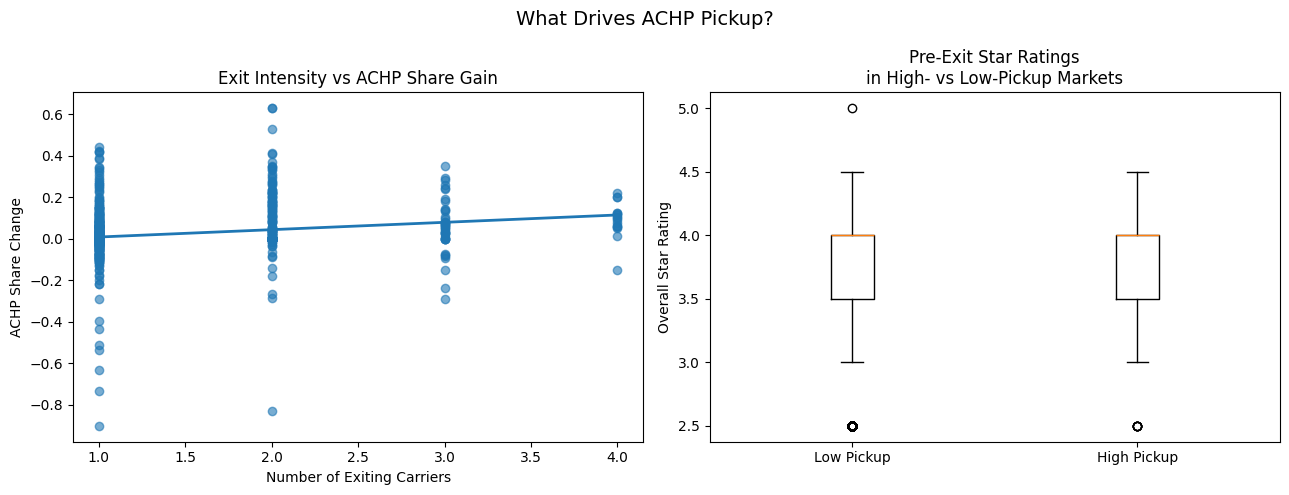

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================
# 图3：What Drives ACHP Pickup?
# 不改原表版本
# 左图：Exit Intensity vs ACHP Share Gain
# 右图：Pre-exit Star Ratings in High- vs Low-Pickup Markets
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# --------------------------------------------------
# 1) 定义仅用于可视化的新标准化函数（不改原表）
# --------------------------------------------------
def norm_county_for_viz(s):
    s = s.astype(str).str.upper().str.strip()
    s = s.str.replace(r"\s+", " ", regex=True)
    s = s.str.replace(r"\bST\.\b", "SAINT", regex=True)
    s = s.str.replace(r"\bSTE\.\b", "SAINTE", regex=True)
    s = s.str.replace(r"\bCOUNTY\b", "", regex=True)
    s = s.str.replace(r"\bPARISH\b", "", regex=True)
    s = s.str.replace(r"\bBOROUGH\b", "", regex=True)
    s = s.str.replace(r"\bCENSUS AREA\b", "", regex=True)
    s = s.str.replace(r"\bCITY AND BOROUGH\b", "", regex=True)
    s = s.str.replace(r"\bCITY\b", "", regex=True)
    s = s.str.replace(r"[^\w\s]", "", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

def clean_numeric_for_viz(s):
    s = s.astype(str).str.strip()
    s = s.str.replace("$", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    s = s.replace({
        "Not Applicable": np.nan,
        "Not Available": np.nan,
        "nan": np.nan,
        "": np.nan
    })
    return pd.to_numeric(s, errors="coerce")

# --------------------------------------------------
# 2) 从原表复制出可视化专用表，不改原表
# --------------------------------------------------

# 2.1 county_change_exit -> county_change_exit_viz
county_change_exit_viz = county_change_exit.copy()

county_change_exit_viz["state_abbr_viz"] = (
    county_change_exit_viz["state_abbr"]
    .astype(str)
    .str.upper()
    .str.strip()
)

county_change_exit_viz["county_norm_viz"] = norm_county_for_viz(
    county_change_exit_viz["county_norm"]
)

# 2.2 exit_by_county -> exit_by_county_viz
exit_by_county_viz = exit_by_county.copy()

exit_by_county_viz["state_abbr_viz"] = (
    exit_by_county_viz["state_abbr"]
    .astype(str)
    .str.upper()
    .str.strip()
)

exit_by_county_viz["county_norm_viz"] = norm_county_for_viz(
    exit_by_county_viz["County Name"]
)

# 2.3 exit_detail_B -> exit_detail_B_viz
exit_detail_B_viz = exit_detail_B.copy()

exit_detail_B_viz["state_abbr_viz"] = (
    exit_detail_B_viz["state_abbr"]
    .astype(str)
    .str.upper()
    .str.strip()
)

exit_detail_B_viz["county_norm_viz"] = norm_county_for_viz(
    exit_detail_B_viz["county_norm"]
)

# --------------------------------------------------
# 3) 生成散点图数据：退出强度 vs pickup 强度
# --------------------------------------------------
scatter_df_viz = county_change_exit_viz.merge(
    exit_by_county_viz[
        ["state_abbr_viz", "county_norm_viz", "num_exiting_carriers"]
    ],
    on=["state_abbr_viz", "county_norm_viz"],
    how="left"
)

scatter_df_viz = scatter_df_viz.dropna(
    subset=["num_exiting_carriers", "share_delta"]
).copy()

# 可选：检查
print("scatter_df_viz shape:", scatter_df_viz.shape)
display(
    scatter_df_viz[
        ["state_abbr", "county_norm", "num_exiting_carriers", "share_delta", "achp_delta"]
    ].head()
)

# --------------------------------------------------
# 4) 定义高 pickup / 低 pickup 分组（不改原表）
# --------------------------------------------------
pickup_groups_viz = county_change_exit.copy()

pickup_groups_viz["state_abbr_viz"] = (
    pickup_groups_viz["state_abbr"]
    .astype(str)
    .str.upper()
    .str.strip()
)

pickup_groups_viz["county_norm_viz"] = norm_county_for_viz(
    pickup_groups_viz["county_norm"]
)

q75 = pickup_groups_viz["share_delta"].quantile(0.75)
q25 = pickup_groups_viz["share_delta"].quantile(0.25)

pickup_groups_viz["pickup_group"] = np.where(
    pickup_groups_viz["share_delta"] >= q75,
    "High Pickup",
    np.where(
        pickup_groups_viz["share_delta"] <= q25,
        "Low Pickup",
        "Middle"
    )
)

pickup_groups_viz = pickup_groups_viz[
    pickup_groups_viz["pickup_group"] != "Middle"
].copy()

print("pickup_groups_viz counts:")
print(pickup_groups_viz["pickup_group"].value_counts())

# --------------------------------------------------
# 5) 识别 Star Rating 字段，并清洗为数值列（不改原表）
# --------------------------------------------------
candidate_star_cols = [
    "Overall Star Rating",
    "Overall Star Rating ",
    "Part C Summary Star Rating",
    "Part C Summary Star Rating "
]

star_col = None
for c in candidate_star_cols:
    if c in exit_detail_B_viz.columns:
        star_col = c
        break

if star_col is None:
    raise ValueError("未找到 Star Rating 字段，请检查 exit_detail_B 的列名。")

exit_detail_B_viz["star_num_viz"] = clean_numeric_for_viz(
    exit_detail_B_viz[star_col]
)

print("Using star column:", star_col)

# --------------------------------------------------
# 6) 合并高/低 pickup 分组到退出产品明细（不改原表）
# --------------------------------------------------
box_df_viz = exit_detail_B_viz.merge(
    pickup_groups_viz[
        ["state_abbr_viz", "county_norm_viz", "pickup_group"]
    ],
    on=["state_abbr_viz", "county_norm_viz"],
    how="inner"
)

box_df_viz = box_df_viz.dropna(
    subset=["star_num_viz", "pickup_group"]
).copy()

print("box_df_viz shape:", box_df_viz.shape)
display(
    box_df_viz[
        ["state_abbr", "county_norm", "pickup_group", star_col, "star_num_viz"]
    ].head()
)

# --------------------------------------------------
# 7) 准备箱线图数据
# --------------------------------------------------
low_star_viz = box_df_viz.loc[
    box_df_viz["pickup_group"] == "Low Pickup",
    "star_num_viz"
].copy()

high_star_viz = box_df_viz.loc[
    box_df_viz["pickup_group"] == "High Pickup",
    "star_num_viz"
].copy()

print("Low Pickup star count:", low_star_viz.shape[0])
print("High Pickup star count:", high_star_viz.shape[0])

# --------------------------------------------------
# 8) 画第三个 PPT 图片
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左图：退出强度 vs pickup 强度
x = scatter_df_viz["num_exiting_carriers"].astype(float)
y = scatter_df_viz["share_delta"].astype(float)

axes[0].scatter(x, y, alpha=0.6)

# 趋势线
if len(scatter_df_viz) > 1:
    coef = np.polyfit(x, y, 1)
    trend = np.poly1d(coef)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(x_line, trend(x_line), linewidth=2)

axes[0].set_xlabel("Number of Exiting Carriers")
axes[0].set_ylabel("ACHP Share Change")
axes[0].set_title("Exit Intensity vs ACHP Share Gain")

# 右图：高 pickup vs 低 pickup 的星级分布
axes[1].boxplot(
    [low_star_viz, high_star_viz],
    labels=["Low Pickup", "High Pickup"]
)
axes[1].set_ylabel("Overall Star Rating")
axes[1].set_title("Pre-Exit Star Ratings\nin High- vs Low-Pickup Markets")

fig.suptitle("What Drives ACHP Pickup?", fontsize=14)
plt.tight_layout()

# 保存
output_file = "achp_pickup_drivers.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight")
plt.show()

# 下载
files.download(output_file)

pickup_groups_viz counts:
pickup_group
Low Pickup     907
High Pickup    312
Name: count, dtype: int64


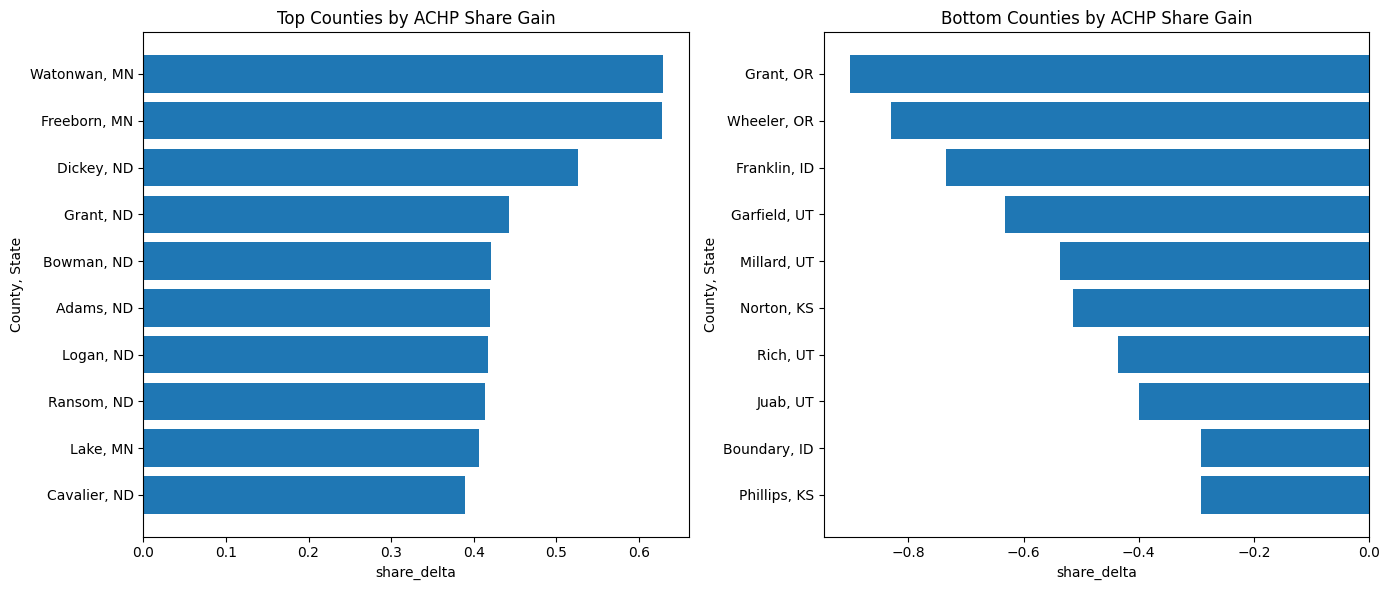

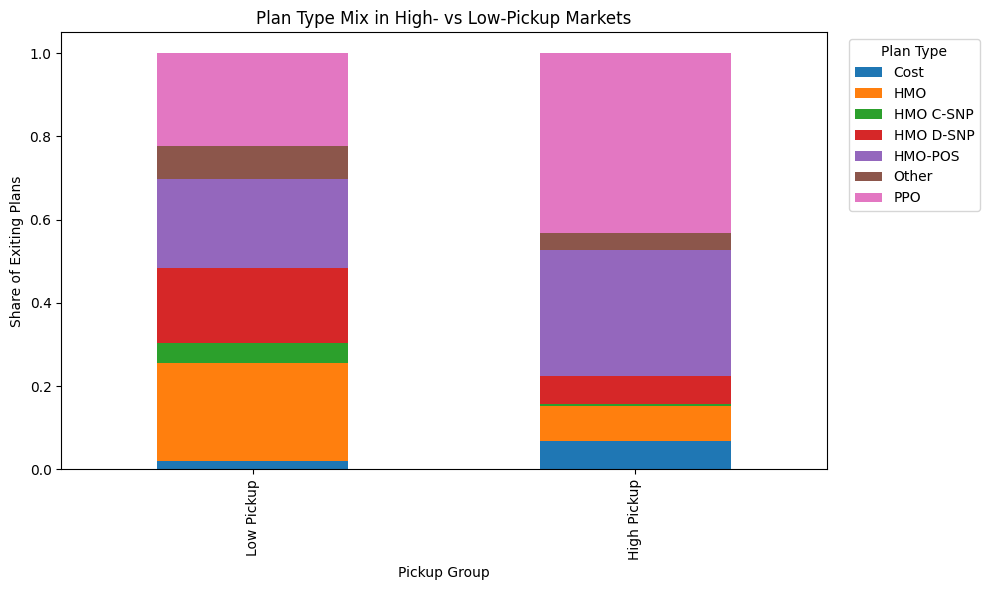

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# Page 4 charts
# A) Top / Bottom Counties by ACHP Share Gain
# B) Plan Type Mix in High- vs Low-Pickup Markets
# 不改原表版本：全部 copy 新表后再处理
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --------------------------------------------------
# 0) 定义可视化专用函数（不改原表）
# --------------------------------------------------
def norm_county_for_viz(s):
    s = s.astype(str).str.upper().str.strip()
    s = s.str.replace(r"\s+", " ", regex=True)
    s = s.str.replace(r"\bST\.\b", "SAINT", regex=True)
    s = s.str.replace(r"\bSTE\.\b", "SAINTE", regex=True)
    s = s.str.replace(r"\bCOUNTY\b", "", regex=True)
    s = s.str.replace(r"\bPARISH\b", "", regex=True)
    s = s.str.replace(r"\bBOROUGH\b", "", regex=True)
    s = s.str.replace(r"\bCENSUS AREA\b", "", regex=True)
    s = s.str.replace(r"\bCITY AND BOROUGH\b", "", regex=True)
    s = s.str.replace(r"\bCITY\b", "", regex=True)
    s = s.str.replace(r"[^\w\s]", "", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

# --------------------------------------------------
# 1) 复制原表，生成可视化专用表
# --------------------------------------------------

# 1.1 county_change_exit -> county_change_exit_viz
county_change_exit_viz = county_change_exit.copy()

county_change_exit_viz["state_abbr_viz"] = (
    county_change_exit_viz["state_abbr"]
    .astype(str)
    .str.upper()
    .str.strip()
)

county_change_exit_viz["county_norm_viz"] = norm_county_for_viz(
    county_change_exit_viz["county_norm"]
)

# 如果没有 County Name，就用 county_norm 代替展示名
if "County Name" not in county_change_exit_viz.columns:
    county_change_exit_viz["County Name"] = county_change_exit_viz["county_norm"]

county_change_exit_viz["county_label_viz"] = (
    county_change_exit_viz["County Name"].astype(str).str.strip()
    + ", "
    + county_change_exit_viz["state_abbr"].astype(str).str.strip()
)

# 1.2 exit_detail_B -> exit_detail_B_viz
exit_detail_B_viz = exit_detail_B.copy()

exit_detail_B_viz["state_abbr_viz"] = (
    exit_detail_B_viz["state_abbr"]
    .astype(str)
    .str.upper()
    .str.strip()
)

exit_detail_B_viz["county_norm_viz"] = norm_county_for_viz(
    exit_detail_B_viz["county_norm"]
)

# --------------------------------------------------
# 2) 定义 High Pickup / Low Pickup（不改原表）
# --------------------------------------------------
pickup_groups_viz = county_change_exit_viz.copy()

q75 = pickup_groups_viz["share_delta"].quantile(0.75)
q25 = pickup_groups_viz["share_delta"].quantile(0.25)

pickup_groups_viz["pickup_group"] = np.where(
    pickup_groups_viz["share_delta"] >= q75,
    "High Pickup",
    np.where(
        pickup_groups_viz["share_delta"] <= q25,
        "Low Pickup",
        "Middle"
    )
)

pickup_groups_viz = pickup_groups_viz[
    pickup_groups_viz["pickup_group"] != "Middle"
].copy()

print("pickup_groups_viz counts:")
print(pickup_groups_viz["pickup_group"].value_counts())

# --------------------------------------------------
# 3) 图 A: Top / Bottom Counties by ACHP Share Gain
# --------------------------------------------------
county_rank_viz = county_change_exit_viz.copy()

# 去掉 share_delta 缺失
county_rank_viz = county_rank_viz.dropna(subset=["share_delta"]).copy()

top_n = 10

top_counties_viz = (
    county_rank_viz
    .sort_values("share_delta", ascending=False)
    .head(top_n)
    .copy()
)

bottom_counties_viz = (
    county_rank_viz
    .sort_values("share_delta", ascending=True)
    .head(top_n)
    .copy()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左：Top counties
axes[0].barh(
    top_counties_viz["county_label_viz"][::-1],
    top_counties_viz["share_delta"][::-1]
)
axes[0].set_title("Top Counties by ACHP Share Gain")
axes[0].set_xlabel("share_delta")
axes[0].set_ylabel("County, State")

# 右：Bottom counties
axes[1].barh(
    bottom_counties_viz["county_label_viz"][::-1],
    bottom_counties_viz["share_delta"][::-1]
)
axes[1].set_title("Bottom Counties by ACHP Share Gain")
axes[1].set_xlabel("share_delta")
axes[1].set_ylabel("County, State")

plt.tight_layout()
plt.savefig("top_bottom_counties_share_gain.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# 4) 图 B: Plan Type Mix in High- vs Low-Pickup Markets
# --------------------------------------------------

# 寻找 Plan Type 字段
plan_type_col = None
for c in ["Plan Type", "Plan Type "]:
    if c in exit_detail_B_viz.columns:
        plan_type_col = c
        break

if plan_type_col is None:
    raise ValueError("未找到 Plan Type 字段，请检查 exit_detail_B 的列名。")

# 合并 pickup 分组到计划明细
detail_pickup_viz = exit_detail_B_viz.merge(
    pickup_groups_viz[
        ["state_abbr_viz", "county_norm_viz", "pickup_group"]
    ],
    on=["state_abbr_viz", "county_norm_viz"],
    how="inner"
)

# 清洗/归并 Plan Type
plan_type_mix_viz = detail_pickup_viz.copy()

plan_type_mix_viz["plan_type_viz"] = (
    plan_type_mix_viz[plan_type_col]
    .astype(str)
    .str.strip()
    .replace({"": "Unknown", "nan": "Unknown"})
)

# 只保留出现频率最高的前 6 类，其余并成 Other
top_types = (
    plan_type_mix_viz["plan_type_viz"]
    .value_counts()
    .head(6)
    .index
    .tolist()
)

plan_type_mix_viz["plan_type_grouped_viz"] = np.where(
    plan_type_mix_viz["plan_type_viz"].isin(top_types),
    plan_type_mix_viz["plan_type_viz"],
    "Other"
)

# 生成占比表
plan_type_tab_viz = pd.crosstab(
    plan_type_mix_viz["pickup_group"],
    plan_type_mix_viz["plan_type_grouped_viz"],
    normalize="index"
)

# 保证显示顺序
desired_index = [i for i in ["Low Pickup", "High Pickup"] if i in plan_type_tab_viz.index]
plan_type_tab_viz = plan_type_tab_viz.loc[desired_index]

ax = plan_type_tab_viz.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

ax.set_title("Plan Type Mix in High- vs Low-Pickup Markets")
ax.set_xlabel("Pickup Group")
ax.set_ylabel("Share of Exiting Plans")

plt.legend(title="Plan Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("plan_type_mix_high_vs_low_pickup.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# 5) 下载图片
# --------------------------------------------------
files.download("top_bottom_counties_share_gain.png")
files.download("plan_type_mix_high_vs_low_pickup.png")